**2nd Assignment - Penglihatan Komputer dan Analisis Citra** <br>
**Farsya Nabila Tori [24/543855/PA/23113]**

*Implement one of the object detection methods to solve certain problem without using library. Give analysis of your results in term of accuracy and IoU.*

##**Object Detection**



Pada piramida pemrosesan informasi dalam *computer vision,* deteksi termasuk tahap paling dasar atau yang pertama untuk dilakukan. Tujuannya adalah untuk mengetahui eksistensi objek, lokasi objek, dan jumlahnya. Setelah deteksi, secara berurutan, dilakukan klasifikasi, rekognisi, identifikasi, dan analisis. <br> <br>
Jenis metode deteksi bergantung pada jenis objeknya dan berdasarkan hal tersebut, ia setidaknya terbagi menjadi tiga jenis, yakni <br>
**(1) Segmentasi:** digunakan untuk objek yang sifatnya homogen dan menghasilkan luaran berupa ROI (Region of Interest) dengan bentuk yang tidak pasti. Misal, dilakukannya deteksi pada tumor, jerawat, jeruk, eritrosit, dan api yang hanya memiliki beberapa warna untuk jenisnya (homogen). <br>
**(2) Sliding Window:** digunakan untuk objek yang karakteristiknya heterogen, seperti warnanya yang bervariasi. Luarannya berupa Object of Interest (OII) atau bounding box. Misalnya, sliding window pada ikan karena warnanya yang sangat bervariasi dan tidak pasti. <br>
**(3) Background Modeling:** digunakan pada objek yang bergerak dan luarannya dapat berupa OII ataupun ROI. Misalnya, untuk pendeteksian orang, ikan, ombak, api, dan lainnya. <br> <br> Pada tugas kali ini, dilakukan deteksi objek menggunakan segmentasi, yakni sebagai berikut.



###**Segmentasi**

Dilakukan dengan pipeline berupa: **Input → Thresholding → Binary Image → CCL → Bounding Box.** <br>

*  **Thresholding + Binary Image:** bagian segmentasi yang memisahkan *foreground* dan *background* dengan mengklasifikasi piksel satu per satu *(pixel-based).*
*   **CCL:** bagian dari segmentasi yang mengelompokkan piksel *foreground* yang terkoneksi menjadi satu region.
*   **Bounding Box:** hasil deteksi objek yang berupa lokasi objek, jumlah objek, dan posisi sentroid. <br>

Segmentasi dilakukan pada dua jenis buah, yakni jeruk dan pisang. Pada gambar jeruk, ia akan diuji pada dua jenis latar belakang, yakni (1) background kompleks; (2) background kontras.




#### **Jeruk**

Pada gambar jeruk ini, tantangannya terletak pada *background* yang cukup kompleks, yakni adanya jeruk utuh, jeruk terbelah dua, dan jeruk yang sudah dimakan, terletak di atas talenan cokelat-oranye, mirip jeruk. Ground Truth (GT) pada gambar ini dibagi menjadi lima objek, yaitu
*   GT1: jeruk belah atas  (talenan)
*   GT2: jeruk belah bawah (talenan)
*   GT3: jeruk belah atas (keranjang)
*   GT4: jeruk belah bawah (keranjang)
*   GT5: jeruk utuh (keranjang) <br> <br>
 ![gambar jeruk bg kompleks](https://drive.google.com/uc?export=download&id=1kQbmgiwa00iuDcsRTsVhfxGpmZH7te1S) <br>






File tersimpan sebagai: jeruk1.jpg
[1] Load citra
    Ukuran: 800 × 533 piksel
[2] Konversi RGB → HSV
[3] HSV Color Thresholding
    Piksel foreground: 22,675 / 426,400
[4] Morphological Opening (k=5) → Closing (k=5)
[5] Connected Component Labeling (CCL 4-connectivity)
    Blob ditemukan: 5
[6] Ekstrak Bounding Box (min_area=800px)
    Objek lolos filter: 4
      Pred1: [329,165,399,209]  area=2094px  centroid=(366, 188)
      Pred2: [274,212,367,305]  area=3299px  centroid=(315, 265)
      Pred3: [582,254,653,328]  area=3026px  centroid=(615, 291)
      Pred4: [499,300,657,444]  area=11012px  centroid=(584, 373)

[7] Perhitungan IoU per prediksi:
Pred1 [329, 165, 399, 209]  ↔  GT1 [278, 68, 412, 218]
    Intersection : (399-329) × (209-165) = 3080 px²
    Area Pred    : (399-329) × (209-165) = 3080 px²
    Area GT      : (412-278) × (218-68) = 20100 px²
    Union        : 3080 + 20100 - 3080 = 20100 px²
    IoU          : 3080 / 20100 = 0.1532
Pred2 [274, 212, 367, 305]  ↔  GT2 [240,

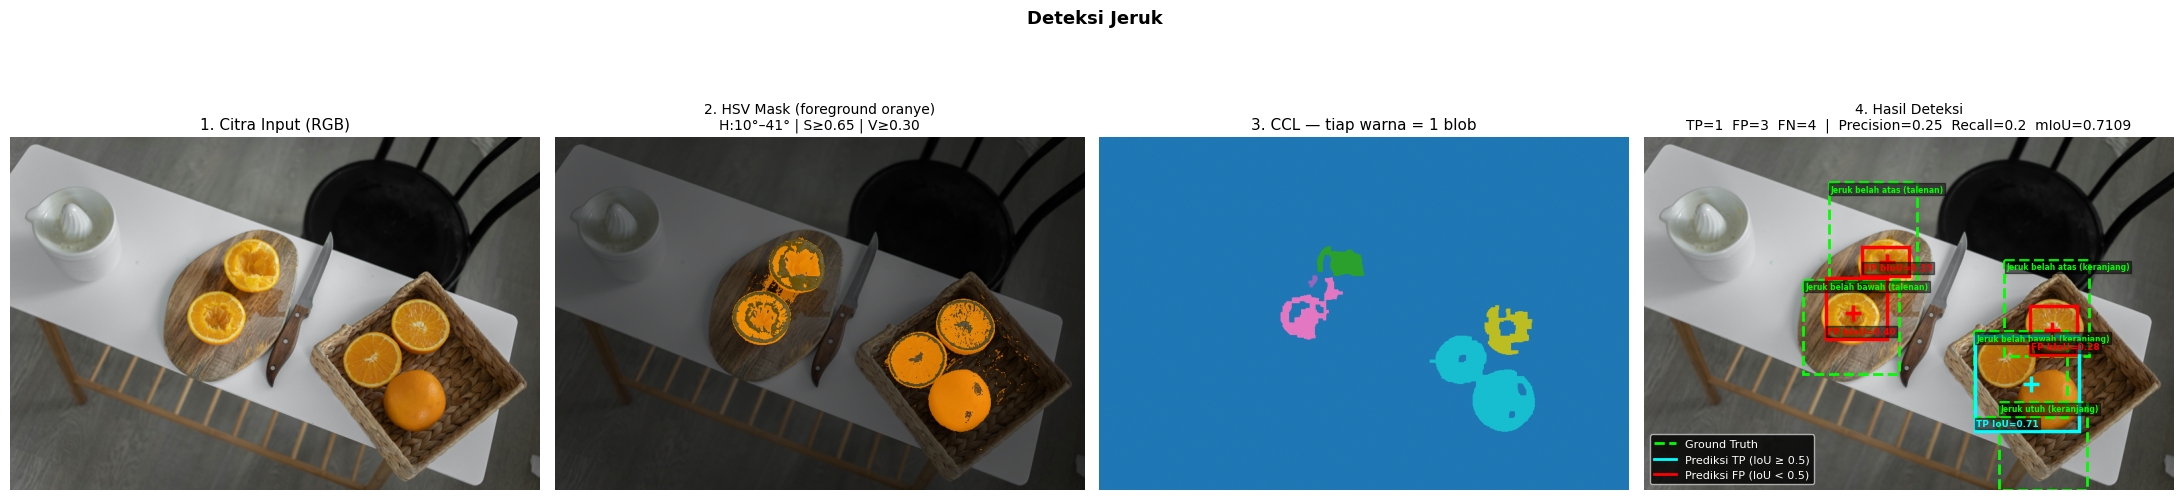

Visualisasi disimpan: hasil_deteksi_jeruk1.png


In [29]:
import urllib.request
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

URL        = "https://drive.google.com/uc?export=download&id=1kQbmgiwa00iuDcsRTsVhfxGpmZH7te1S"
IMAGE_PATH = "jeruk1.jpg"
urllib.request.urlretrieve(URL, IMAGE_PATH)
print("File tersimpan sebagai:", IMAGE_PATH)

# Bounding box [x1, y1, x2, y2]
GT_BOXES = [
    [278, 68,  412, 218],   # GT1
    [240, 215, 385, 358],   # GT2
    [543, 185, 672, 330],   # GT3
    [498, 293, 638, 422],   # GT4
    [535, 400, 668, 532],   # GT5
]
GT_LABELS = [
    "Jeruk belah atas (talenan)",
    "Jeruk belah bawah (talenan)",
    "Jeruk belah atas (keranjang)",
    "Jeruk belah bawah (keranjang)",
    "Jeruk utuh (keranjang)",
]

# (1) RGB → HSV
def rgb_to_hsv(img_rgb):
    r = img_rgb[:,:,0] / 255.0
    g = img_rgb[:,:,1] / 255.0
    b = img_rgb[:,:,2] / 255.0

    Cmax  = np.maximum(np.maximum(r, g), b)
    Cmin  = np.minimum(np.minimum(r, g), b)
    delta = Cmax - Cmin

    V = Cmax
    S = np.where(Cmax > 0, delta / Cmax, 0.0)

    H   = np.zeros_like(V)
    m_r = (Cmax == r) & (delta > 0)
    m_g = (Cmax == g) & (delta > 0)
    m_b = (Cmax == b) & (delta > 0)
    H[m_r] = (60 * ((g[m_r] - b[m_r]) / delta[m_r]) % 360) / 360
    H[m_g] = (60 * ((b[m_g] - r[m_g]) / delta[m_g] + 2) % 360) / 360
    H[m_b] = (60 * ((r[m_b] - g[m_b]) / delta[m_b] + 4) % 360) / 360
    return H, S, V


# (2) HSV Color Thresholding
def color_threshold(H, S, V, h_min=0.028, h_max=0.115, s_min=0.72, v_min=0.30):
    return ((H >= h_min) & (H <= h_max) &
            (S >= s_min) & (V >= v_min)).astype(np.uint8)


# (3) Morphological Operations
def erode(binary, k=3):
    H, W = binary.shape; p = k // 2
    out  = np.zeros_like(binary)
    for y in range(p, H - p):
        for x in range(p, W - p):
            if binary[y-p:y+p+1, x-p:x+p+1].sum() == k * k:
                out[y, x] = 1
    return out

def dilate(binary, k=3):
    H, W = binary.shape; p = k // 2
    out  = np.zeros_like(binary)
    for y in range(p, H - p):
        for x in range(p, W - p):
            if binary[y-p:y+p+1, x-p:x+p+1].sum() > 0:
                out[y, x] = 1
    return out

def opening(binary, k=5):
    return dilate(erode(binary, k), k)

def closing(binary, k=7):
    return erode(dilate(binary, k), k)


# (4) CCL
def ccl_4connectivity(binary):
    H, W      = binary.shape
    label_map = np.zeros((H, W), dtype=np.int32)
    parent    = [0]; next_lbl = 1

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    for y in range(H):
        for x in range(W):
            if binary[y, x] == 0: continue
            nb = []
            if y > 0 and label_map[y-1, x] > 0: nb.append(label_map[y-1, x])
            if x > 0 and label_map[y, x-1] > 0: nb.append(label_map[y, x-1])
            if not nb:
                parent.append(next_lbl); label_map[y, x] = next_lbl; next_lbl += 1
            else:
                label_map[y, x] = nb[0]
                for n in nb[1:]: union(nb[0], n)

    resolved = {}; n_labels = 0
    for y in range(H):
        for x in range(W):
            lbl = label_map[y, x]
            if lbl == 0: continue
            root = find(lbl)
            if root not in resolved: n_labels += 1; resolved[root] = n_labels
            label_map[y, x] = resolved[root]
    return label_map, n_labels


# (5) Bounding Box Extraction
def extract_boxes(label_map, n_labels, min_area=800):
    boxes = []
    for lbl in range(1, n_labels + 1):
        ys, xs = np.where(label_map == lbl)
        if len(ys) < min_area: continue
        boxes.append({
            "label": lbl,
            "x1": int(xs.min()), "y1": int(ys.min()),
            "x2": int(xs.max()), "y2": int(ys.max()),
            "area": int(len(ys)),
            "centroid": (int(xs.mean()), int(ys.mean())),
        })
    boxes.sort(key=lambda b: (b["y1"] + b["y2"]) / 2)
    return boxes


# (6) Evaluasi: IoU, Precision, Recall
def compute_iou(a, b, verbose=False):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])

    if ix2 <= ix1 or iy2 <= iy1:
        inter = 0
    else:
        inter = (ix2 - ix1) * (iy2 - iy1)

    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union  = area_a + area_b - inter

    iou_val = inter / union if union > 0 else 0.0

    if verbose:
        print(f"    Intersection : ({ix2}-{ix1}) × ({iy2}-{iy1}) = {inter} px²")
        print(f"    Area Pred    : ({a[2]}-{a[0]}) × ({a[3]}-{a[1]}) = {area_a} px²")
        print(f"    Area GT      : ({b[2]}-{b[0]}) × ({b[3]}-{b[1]}) = {area_b} px²")
        print(f"    Union        : {area_a} + {area_b} - {inter} = {union} px²")
        print(f"    IoU          : {inter} / {union} = {iou_val:.4f}")

    return iou_val


def evaluate(pred_boxes, gt_boxes, iou_threshold=0.5):
    pairs = []
    for pi, pb in enumerate(pred_boxes):
        pbl = [pb["x1"], pb["y1"], pb["x2"], pb["y2"]]
        for gi, gb in enumerate(gt_boxes):
            pairs.append((compute_iou(pbl, gb), pi, gi))
    pairs.sort(key=lambda t: -t[0])

    matched_p, matched_g = set(), set()
    iou_vals = {}
    for v, pi, gi in pairs:
        if pi in matched_p or gi in matched_g: continue
        if v >= iou_threshold:
            matched_p.add(pi); matched_g.add(gi); iou_vals[pi] = v

    best_iou = {}
    for v, pi, _ in sorted(pairs, key=lambda t: -t[0]):
        if pi not in best_iou: best_iou[pi] = v

    TP = len(matched_p); FP = len(pred_boxes) - TP; FN = len(gt_boxes) - TP
    P  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    R  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    F1 = 2*P*R / (P + R) if (P + R) > 0 else 0.0
    mIoU = float(np.mean(list(iou_vals.values()))) if iou_vals else 0.0

    return {"TP": TP, "FP": FP, "FN": FN,
            "Precision": round(P, 4), "Recall": round(R, 4),
            "F1-Score": round(F1, 4), "mIoU": round(mIoU, 4)
            }, best_iou, matched_p


# (7) Visualisasi
def visualize(img_rgb, mask_raw, label_map, pred_boxes,
              gt_boxes, gt_labels, metrics, best_iou, matched_p):
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(
        "Deteksi Jeruk",
        fontsize=13, fontweight='bold')

    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Citra Input (RGB)", fontsize=11); axes[0].axis('off')

    overlay = np.zeros((*img_rgb.shape[:2], 3), dtype=np.uint8)
    overlay[mask_raw == 1] = [255, 140, 0]
    blended = (img_rgb.astype(np.float32)*0.45 +
               overlay.astype(np.float32)*0.55).clip(0,255).astype(np.uint8)
    axes[1].imshow(blended)
    axes[1].set_title("2. HSV Mask (foreground oranye)\nH:10°–41° | S≥0.65 | V≥0.30", fontsize=10)
    axes[1].axis('off')

    axes[2].imshow(label_map, cmap='tab10')
    axes[2].set_title("3. CCL — tiap warna = 1 blob", fontsize=11); axes[2].axis('off')

    axes[3].imshow(img_rgb)
    for i, gt in enumerate(gt_boxes):
        axes[3].add_patch(patches.Rectangle(
            (gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
            lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
        axes[3].text(gt[0]+3, gt[1]+14, gt_labels[i], color='lime',
                     fontsize=5.5, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))

    for i, b in enumerate(pred_boxes):
        iou_v = best_iou.get(i, 0.0); is_tp = i in matched_p
        color = 'cyan' if is_tp else 'red'
        tag   = f"TP IoU={iou_v:.2f}" if is_tp else \
                (f"FP bIoU={iou_v:.2f}" if iou_v > 0 else "FP")
        axes[3].add_patch(patches.Rectangle(
            (b["x1"], b["y1"]), b["x2"]-b["x1"], b["y2"]-b["y1"],
            lw=2.5, edgecolor=color, facecolor='none'))
        axes[3].text(b["x1"]+2, b["y2"]-8, tag, color=color, fontsize=6.5,
                     fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=1))
        cx, cy = b["centroid"]; axes[3].plot(cx, cy, '+', color=color, markersize=11, mew=2.5)

    legend = [Line2D([0],[0], color='lime', ls='--', lw=2, label='Ground Truth'),
              Line2D([0],[0], color='cyan', ls='-',  lw=2, label='Prediksi TP (IoU ≥ 0.5)'),
              Line2D([0],[0], color='red',  ls='-',  lw=2, label='Prediksi FP (IoU < 0.5)')]
    axes[3].legend(handles=legend, fontsize=8, loc='lower left',
                   facecolor='black', labelcolor='white')
    axes[3].set_title(
        f"4. Hasil Deteksi\n"
        f"TP={metrics['TP']}  FP={metrics['FP']}  FN={metrics['FN']}  |  "
        f"Precision={metrics['Precision']}  Recall={metrics['Recall']}  mIoU={metrics['mIoU']}",
        fontsize=10)
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig("hasil_deteksi_jeruk1.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Visualisasi disimpan: hasil_deteksi_jeruk1.png")

def main():
    print("[1] Load citra")
    pil     = Image.open(IMAGE_PATH).convert("RGB")
    pil     = pil.resize((800, 533))
    img_rgb = np.array(pil)
    print(f"    Ukuran: {img_rgb.shape[1]} × {img_rgb.shape[0]} piksel")

    print("[2] Konversi RGB → HSV")
    H, S, V = rgb_to_hsv(img_rgb)

    print("[3] HSV Color Thresholding")
    mask_raw = color_threshold(H, S, V, h_min=0.028, h_max=0.115, s_min=0.72, v_min=0.30)
    print(f"    Piksel foreground: {mask_raw.sum():,} / {mask_raw.size:,}")

    print("[4] Morphological Opening (k=5) → Closing (k=5)")
    binary = closing(opening(mask_raw, k=5), k=7)

    print("[5] Connected Component Labeling (CCL 4-connectivity)")
    label_map, n_raw = ccl_4connectivity(binary)
    print(f"    Blob ditemukan: {n_raw}")

    MIN_AREA = 800
    print(f"[6] Ekstrak Bounding Box (min_area={MIN_AREA}px)")
    pred_boxes = extract_boxes(label_map, n_raw, min_area=MIN_AREA)
    print(f"    Objek lolos filter: {len(pred_boxes)}")
    for i, b in enumerate(pred_boxes):
        print(f"      Pred{i+1}: [{b['x1']},{b['y1']},{b['x2']},{b['y2']}]  "
              f"area={b['area']}px  centroid={b['centroid']}")

    print("\n[7] Perhitungan IoU per prediksi:")
    for pi, pb in enumerate(pred_boxes):
        pbl = [pb["x1"], pb["y1"], pb["x2"], pb["y2"]]
        best_v = 0; best_gi = -1
        for gi, gb in enumerate(GT_BOXES):
            v = compute_iou(pbl, gb)
            if v > best_v: best_v = v; best_gi = gi
        if best_gi >= 0:
            print(f"Pred{pi+1} {pbl}  ↔  GT{best_gi+1} {GT_BOXES[best_gi]}")
            compute_iou(pbl, GT_BOXES[best_gi], verbose=True)

    print(f"\n[8] Evaluasi (threshold IoU = 0.5)")
    metrics, best_iou, matched_p = evaluate(pred_boxes, GT_BOXES, iou_threshold=0.5)
    print(f"    TP = {metrics['TP']}  |  FP = {metrics['FP']}  |  FN = {metrics['FN']}")
    print(f"    Precision  = TP/(TP+FP) = {metrics['TP']}/({metrics['TP']}+{metrics['FP']}) = {metrics['Precision']}")
    print(f"    Recall     = TP/(TP+FN) = {metrics['TP']}/({metrics['TP']}+{metrics['FN']}) = {metrics['Recall']}")
    print(f"    F1-Score   = 2×P×R/(P+R) = {metrics['F1-Score']}")
    print(f"    Mean IoU   = {metrics['mIoU']}")

    print("\n[9] Visualisasi")
    visualize(img_rgb, mask_raw, label_map, pred_boxes,
              GT_BOXES, GT_LABELS, metrics, best_iou, matched_p)


if __name__ == "__main__":
    main()

**Analisis Hasil Segmentasi** <br>
Dari lima objek GT yang didefinisikan, pipeline hanya berhasil mendeteksi satu objek yang benar/true positive (TP), yakni Pred4 dengan IoU = 0.7109. Bounding box-nya melingkupi area keranjang bawah dengan baik, intersection sebesar 16.958 px² dari 18.060 px². Hal ini didukung oleh bentuk jeruk yang utuh, tidak terkelupas seperti yang lain, dan karena memiliki kontras warna yang cukup kuat terhadap background keranjang rotan di sekitarnya. <br> <br>
Sementara itu, tiga prediksi lainnya berupa false postive (FP) atau yang bukan jeruk, tetapi terdeteksi sebagai jeruk, ditunjukkan dari nilai I0U-nya yang jauh di bawah threshold. Keempat objek lainnya diidentifikasi sebagai false negative (FN) atau yang seharusnya jeruk, tetapi tidak terdeteksi.  <br> <br>

Hanya satu dari empat prediksi yang valid tercermin dari nilai Precision = 0.25. Hanya mampu menemukan satu dari lima objek yang seharusnya terdeteksi ditunjukkan oleh nilai Recall = 0.20. Kombinasi keduanya adalah F1-Score = 0.222, yang secara keseluruhan menggambarkan performa deteksi yang rendah untuk gambar jeruk1 ini.


Selanjutnya, diujikan gambar jeruk pula, tetapi dengan background yang warnanya kontras. Oleh karena tujuannya adalah mendeteksi objek jeruk, GT pada gambar ini adalah sebagai berikut.
*   GT1: jeruk terkupas (atas-tengah)
*   GT2: jeruk kiri-tengah
*   GT3: jeruk bawah-tengah
*   GT4: jeruk kiri-bawah




 ![gambar jeruk bg kontras](https://drive.google.com/uc?export=download&id=1nmi6qx6cGpEoJG824YnZGHglomp1BNHy)

File tersimpan sebagai: jeruk2.jpg
[1] Load citra
    Ukuran: 800 × 533 piksel
[2] Konversi RGB → HSV
[3] HSV Color Thresholding (S_min=0.40, background putih)
    Piksel foreground: 80,111 / 426,400
[4] Morphological Opening (k=5) → Closing (k=9)
[5] Connected Component Labeling (CCL 4-connectivity)
    Blob ditemukan: 6
[6] Ekstrak Bounding Box (min_area=600px)
    Objek lolos filter: 4
      Pred1: [341,34,545,188]  area=18420px  centroid=(429, 104)
      Pred2: [562,153,700,260]  area=4326px  centroid=(628, 215)
      Pred3: [158,143,301,273]  area=14055px  centroid=(228, 207)
      Pred4: [160,261,535,502]  area=42599px  centroid=(341, 377)

[7] Perhitungan IoU per prediksi:
Pred1 [341, 34, 545, 188]  ↔  GT1 [340, 30, 470, 185]
    Intersection : (470-341) × (185-34) = 19479 px²
    Area Pred    : (545-341) × (188-34) = 31416 px²
    Area GT      : (470-340) × (185-30) = 20150 px²
    Union        : 31416 + 20150 - 19479 = 32087 px²
    IoU          : 19479 / 32087 = 0.6071
Pred3 

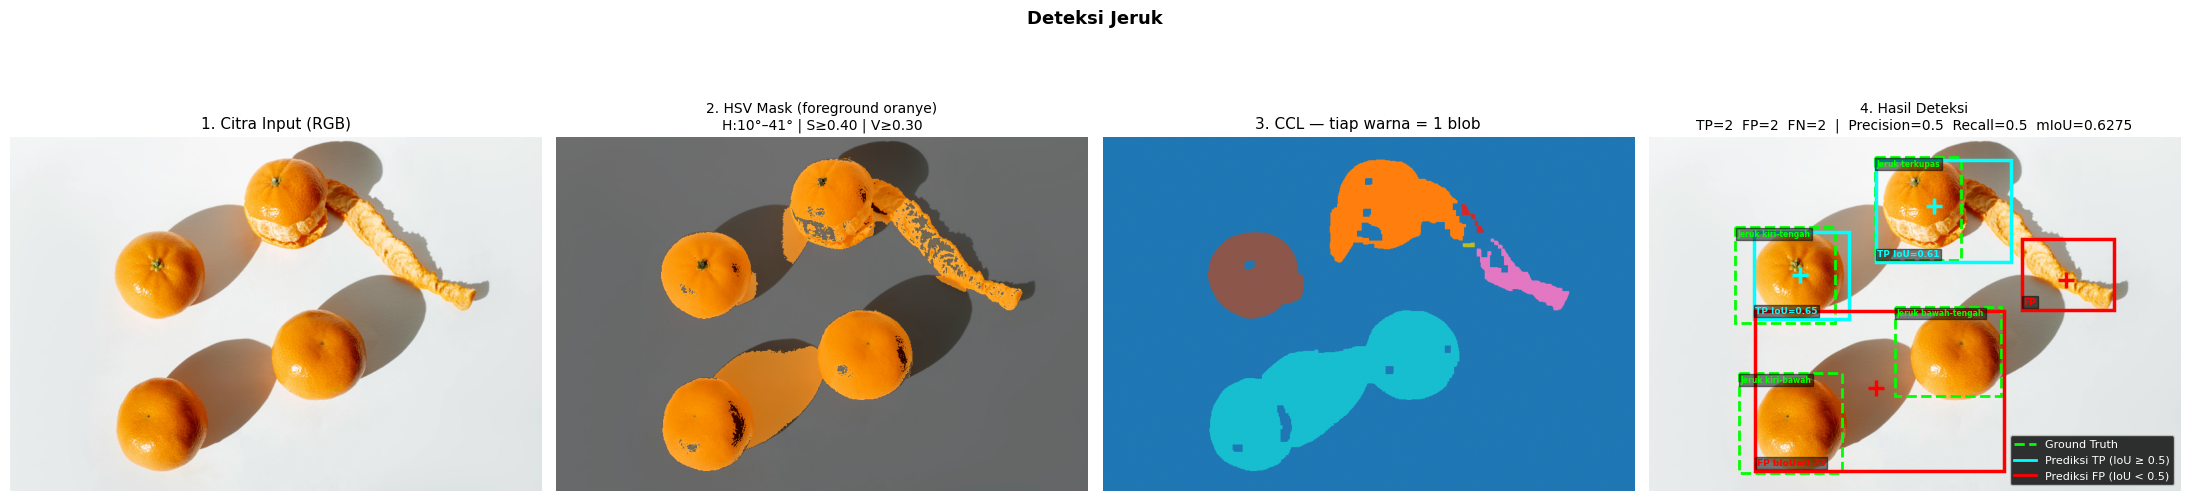

Visualisasi disimpan: hasil_deteksi_jeruk2.png


In [35]:
URL        = "https://drive.google.com/uc?export=download&id=1nmi6qx6cGpEoJG824YnZGHglomp1BNHy"
IMAGE_PATH = "jeruk2.jpg"
urllib.request.urlretrieve(URL, IMAGE_PATH)
print("File tersimpan sebagai:", IMAGE_PATH)

# Bounding box [x1, y1, x2, y2]
GT_BOXES = [
    [340, 30,  470, 185],   # GT1
    [130, 135, 280, 280],   # GT2
    [370, 255, 530, 390],   # GT3
    [135, 355, 290, 505],   # GT4
]
GT_LABELS = [
    "Jeruk terkupas",
    "Jeruk kiri-tengah",
    "Jeruk bawah-tengah",
    "Jeruk kiri-bawah",
]

# (1) RGB → HSV
def rgb_to_hsv(img_rgb):
    r = img_rgb[:,:,0] / 255.0
    g = img_rgb[:,:,1] / 255.0
    b = img_rgb[:,:,2] / 255.0

    Cmax  = np.maximum(np.maximum(r, g), b)
    Cmin  = np.minimum(np.minimum(r, g), b)
    delta = Cmax - Cmin

    V = Cmax
    S = np.where(Cmax > 0, delta / Cmax, 0.0)

    H   = np.zeros_like(V)
    m_r = (Cmax == r) & (delta > 0)
    m_g = (Cmax == g) & (delta > 0)
    m_b = (Cmax == b) & (delta > 0)
    H[m_r] = (60 * ((g[m_r] - b[m_r]) / delta[m_r]) % 360) / 360
    H[m_g] = (60 * ((b[m_g] - r[m_g]) / delta[m_g] + 2) % 360) / 360
    H[m_b] = (60 * ((r[m_b] - g[m_b]) / delta[m_b] + 4) % 360) / 360
    return H, S, V


# (2) HSV Color Thresholding
def color_threshold(H, S, V, h_min=0.028, h_max=0.130, s_min=0.40, v_min=0.45):
    return ((H >= h_min) & (H <= h_max) &
            (S >= s_min) & (V >= v_min)).astype(np.uint8)


# (3) Morphological Operations
def erode(binary, k=3):
    H, W = binary.shape; p = k // 2
    out  = np.zeros_like(binary)
    for y in range(p, H - p):
        for x in range(p, W - p):
            if binary[y-p:y+p+1, x-p:x+p+1].sum() == k * k:
                out[y, x] = 1
    return out

def dilate(binary, k=3):
    H, W = binary.shape; p = k // 2
    out  = np.zeros_like(binary)
    for y in range(p, H - p):
        for x in range(p, W - p):
            if binary[y-p:y+p+1, x-p:x+p+1].sum() > 0:
                out[y, x] = 1
    return out

def opening(binary, k=5):
    return dilate(erode(binary, k), k)

def closing(binary, k=9):
    return erode(dilate(binary, k), k)


# (4) CCL
def ccl_4connectivity(binary):
    H, W      = binary.shape
    label_map = np.zeros((H, W), dtype=np.int32)
    parent    = [0]; next_lbl = 1

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    for y in range(H):
        for x in range(W):
            if binary[y, x] == 0: continue
            nb = []
            if y > 0 and label_map[y-1, x] > 0: nb.append(label_map[y-1, x])
            if x > 0 and label_map[y, x-1] > 0: nb.append(label_map[y, x-1])
            if not nb:
                parent.append(next_lbl); label_map[y, x] = next_lbl; next_lbl += 1
            else:
                label_map[y, x] = nb[0]
                for n in nb[1:]: union(nb[0], n)

    resolved = {}; n_labels = 0
    for y in range(H):
        for x in range(W):
            lbl = label_map[y, x]
            if lbl == 0: continue
            root = find(lbl)
            if root not in resolved: n_labels += 1; resolved[root] = n_labels
            label_map[y, x] = resolved[root]
    return label_map, n_labels


# (5) Bounding Box
def extract_boxes(label_map, n_labels, min_area=600):
    boxes = []
    for lbl in range(1, n_labels + 1):
        ys, xs = np.where(label_map == lbl)
        if len(ys) < min_area: continue
        boxes.append({
            "label": lbl,
            "x1": int(xs.min()), "y1": int(ys.min()),
            "x2": int(xs.max()), "y2": int(ys.max()),
            "area": int(len(ys)),
            "centroid": (int(xs.mean()), int(ys.mean())),
        })
    boxes.sort(key=lambda b: (b["y1"] + b["y2"]) / 2)
    return boxes


# (6) Evaluasi: IoU, Precision, Recall
def compute_iou(a, b, verbose=False):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])

    inter  = (ix2 - ix1) * (iy2 - iy1) if ix2 > ix1 and iy2 > iy1 else 0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union  = area_a + area_b - inter
    iou_val = inter / union if union > 0 else 0.0

    if verbose:
        print(f"    Intersection : ({ix2}-{ix1}) × ({iy2}-{iy1}) = {inter} px²")
        print(f"    Area Pred    : ({a[2]}-{a[0]}) × ({a[3]}-{a[1]}) = {area_a} px²")
        print(f"    Area GT      : ({b[2]}-{b[0]}) × ({b[3]}-{b[1]}) = {area_b} px²")
        print(f"    Union        : {area_a} + {area_b} - {inter} = {union} px²")
        print(f"    IoU          : {inter} / {union} = {iou_val:.4f}")
    return iou_val


def evaluate(pred_boxes, gt_boxes, iou_threshold=0.5):
    pairs = []
    for pi, pb in enumerate(pred_boxes):
        pbl = [pb["x1"], pb["y1"], pb["x2"], pb["y2"]]
        for gi, gb in enumerate(gt_boxes):
            pairs.append((compute_iou(pbl, gb), pi, gi))
    pairs.sort(key=lambda t: -t[0])

    matched_p, matched_g = set(), set()
    iou_vals = {}
    for v, pi, gi in pairs:
        if pi in matched_p or gi in matched_g: continue
        if v >= iou_threshold:
            matched_p.add(pi); matched_g.add(gi); iou_vals[pi] = v

    best_iou = {}
    for v, pi, _ in sorted(pairs, key=lambda t: -t[0]):
        if pi not in best_iou: best_iou[pi] = v

    TP = len(matched_p); FP = len(pred_boxes) - TP; FN = len(gt_boxes) - TP
    P  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    R  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    F1 = 2*P*R / (P + R) if (P + R) > 0 else 0.0
    mIoU = float(np.mean(list(iou_vals.values()))) if iou_vals else 0.0

    return {"TP": TP, "FP": FP, "FN": FN,
            "Precision": round(P, 4), "Recall": round(R, 4),
            "F1-Score": round(F1, 4), "mIoU": round(mIoU, 4)
            }, best_iou, matched_p


# (7) Visualisasi
def visualize(img_rgb, mask_raw, label_map, pred_boxes,
              gt_boxes, gt_labels, metrics, best_iou, matched_p):
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(
        "Deteksi Jeruk",
        fontsize=13, fontweight='bold')

    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Citra Input (RGB)", fontsize=11); axes[0].axis('off')

    overlay = np.zeros((*img_rgb.shape[:2], 3), dtype=np.uint8)
    overlay[mask_raw == 1] = [255, 140, 0]
    blended = (img_rgb.astype(np.float32)*0.45 +
               overlay.astype(np.float32)*0.55).clip(0,255).astype(np.uint8)
    axes[1].imshow(blended)
    axes[1].set_title("2. HSV Mask (foreground oranye)\nH:10°–41° | S≥0.40 | V≥0.30",
                      fontsize=10); axes[1].axis('off')

    axes[2].imshow(label_map, cmap='tab10')
    axes[2].set_title("3. CCL — tiap warna = 1 blob", fontsize=11); axes[2].axis('off')

    axes[3].imshow(img_rgb)
    for i, gt in enumerate(gt_boxes):
        axes[3].add_patch(patches.Rectangle(
            (gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
            lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
        axes[3].text(gt[0]+3, gt[1]+14, gt_labels[i], color='lime',
                     fontsize=5.5, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))

    for i, b in enumerate(pred_boxes):
        iou_v = best_iou.get(i, 0.0); is_tp = i in matched_p
        color = 'cyan' if is_tp else 'red'
        tag   = f"TP IoU={iou_v:.2f}" if is_tp else \
                (f"FP bIoU={iou_v:.2f}" if iou_v > 0 else "FP")
        axes[3].add_patch(patches.Rectangle(
            (b["x1"], b["y1"]), b["x2"]-b["x1"], b["y2"]-b["y1"],
            lw=2.5, edgecolor=color, facecolor='none'))
        axes[3].text(b["x1"]+2, b["y2"]-8, tag, color=color, fontsize=6.5,
                     fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=1))
        cx, cy = b["centroid"]; axes[3].plot(cx, cy, '+', color=color, markersize=11, mew=2.5)

    legend = [Line2D([0],[0], color='lime', ls='--', lw=2, label='Ground Truth'),
              Line2D([0],[0], color='cyan', ls='-',  lw=2, label='Prediksi TP (IoU ≥ 0.5)'),
              Line2D([0],[0], color='red',  ls='-',  lw=2, label='Prediksi FP (IoU < 0.5)')]
    axes[3].legend(handles=legend, fontsize=8, loc='lower right',
                   facecolor='black', labelcolor='white')
    axes[3].set_title(
        f"4. Hasil Deteksi\n"
        f"TP={metrics['TP']}  FP={metrics['FP']}  FN={metrics['FN']}  |  "
        f"Precision={metrics['Precision']}  Recall={metrics['Recall']}  mIoU={metrics['mIoU']}",
        fontsize=10); axes[3].axis('off')

    plt.tight_layout()
    plt.savefig("hasil_deteksi_jeruk2.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Visualisasi disimpan: hasil_deteksi_jeruk2.png")

def main():
    print("[1] Load citra")
    pil     = Image.open(IMAGE_PATH).convert("RGB")
    pil     = pil.resize((800, 533))
    img_rgb = np.array(pil)
    print(f"    Ukuran: {img_rgb.shape[1]} × {img_rgb.shape[0]} piksel")

    print("[2] Konversi RGB → HSV")
    H, S, V = rgb_to_hsv(img_rgb)

    print("[3] HSV Color Thresholding (S_min=0.40, background putih)")
    mask_raw = color_threshold(H, S, V, h_min=0.028, h_max=0.130, s_min=0.40, v_min=0.45)
    print(f"    Piksel foreground: {mask_raw.sum():,} / {mask_raw.size:,}")

    print("[4] Morphological Opening (k=5) → Closing (k=9)")
    binary = closing(opening(mask_raw, k=5), k=9)

    print("[5] Connected Component Labeling (CCL 4-connectivity)")
    label_map, n_raw = ccl_4connectivity(binary)
    print(f"    Blob ditemukan: {n_raw}")

    MIN_AREA = 600
    print(f"[6] Ekstrak Bounding Box (min_area={MIN_AREA}px)")
    pred_boxes = extract_boxes(label_map, n_raw, min_area=MIN_AREA)
    print(f"    Objek lolos filter: {len(pred_boxes)}")
    for i, b in enumerate(pred_boxes):
        print(f"      Pred{i+1}: [{b['x1']},{b['y1']},{b['x2']},{b['y2']}]  "
              f"area={b['area']}px  centroid={b['centroid']}")

    print("\n[7] Perhitungan IoU per prediksi:")
    for pi, pb in enumerate(pred_boxes):
        pbl = [pb["x1"], pb["y1"], pb["x2"], pb["y2"]]
        best_v = 0; best_gi = -1
        for gi, gb in enumerate(GT_BOXES):
            v = compute_iou(pbl, gb)
            if v > best_v: best_v = v; best_gi = gi
        if best_gi >= 0:
            print(f"Pred{pi+1} {pbl}  ↔  GT{best_gi+1} {GT_BOXES[best_gi]}")
            compute_iou(pbl, GT_BOXES[best_gi], verbose=True)

    print(f"\n[8] Evaluasi (threshold IoU = 0.5)")
    metrics, best_iou, matched_p = evaluate(pred_boxes, GT_BOXES, iou_threshold=0.5)
    print(f"    TP = {metrics['TP']}  |  FP = {metrics['FP']}  |  FN = {metrics['FN']}")
    print(f"    Precision  = TP/(TP+FP) = {metrics['TP']}/({metrics['TP']}+{metrics['FP']}) = {metrics['Precision']}")
    print(f"    Recall     = TP/(TP+FN) = {metrics['TP']}/({metrics['TP']}+{metrics['FN']}) = {metrics['Recall']}")
    print(f"    F1-Score   = 2×P×R/(P+R) = {metrics['F1-Score']}")
    print(f"    Mean IoU   = {metrics['mIoU']}")

    print("\n[9] Visualisasi")
    visualize(img_rgb, mask_raw, label_map, pred_boxes,
              GT_BOXES, GT_LABELS, metrics, best_iou, matched_p)


if __name__ == "__main__":
    main()

**Analisis Hasil Segmentasi** <br>
Dari empat GT yang didefinisikan. terdapat dua deteksi TP dari empat, yakni Pred1 dan Pred3, yang nilai IoU keduanya ≥ 0.5. Sementara Pred2 dan Pred4 ini salah dideteksi sebagai positif atau FP karena gagal melewati threshold. <br> <br>
Pred2 mendeteksi strip kulit di area kanan atas gambar dan membentuk blob tersendiri yang kemudian dicocokkan ke GT, tetapi tidak menemukan pasangan yang cocok. Nilai Precision = Recall = 0.5 dan F1-Score = 0.5 menunjukkan bahwa pipeline berhasil mendeteksi tepat separuh dari objek yang ada dengan tingkat ketepatan juga separuhnya (performa yang lebih seimbang dibanding jeruk1).

#### **Pisang**

Selanjutnya, dilakukan pengujian pada pisang untuk memberikan skenario lain karena bentuknya yang berbeda. Terdapat 6 GT, yakni
*   GT1: pisang terkelupas (kiri atas)
*   GT2: pisang utuh melengkung (tengah atas)
*   GT3: pisang utuh (kanan)
*   GT4: pisang utuh (kiri bawah)
*   GT5: pisang terkelupas (tengah bawah)
*  GT6: pisang terkelupas (kanan bawah)





![gambar pisang](https://drive.google.com/uc?export=download&id=1Ov7KU5TR3HCAfDAqamwZDnF6lH0sUbay)

File tersimpan sebagai: pisang.jpg
[1] Load citra
    Ukuran: 800 × 533 piksel
[2] Konversi RGB → HSV
[3] HSV Color Thresholding (background teal)
    Piksel foreground: 63,305 / 426,400
[4] Morphological Opening (k=5) → Closing (k=9)
[5] Connected Component Labeling (CCL 4-connectivity)
    Blob ditemukan: 20
[6] Ekstrak Bounding Box (min_area=800px)
    Objek lolos filter: 8
      Pred1: [152,8,343,184]  area=12303px  centroid=(262, 80)
      Pred2: [567,8,693,248]  area=10497px  centroid=(644, 146)
      Pred3: [371,75,518,263]  area=9743px  centroid=(458, 144)
      Pred4: [64,181,221,387]  area=10328px  centroid=(126, 256)
      Pred5: [509,290,588,395]  area=1911px  centroid=(553, 345)
      Pred6: [380,299,515,447]  area=5166px  centroid=(449, 340)
      Pred7: [194,357,259,458]  area=3344px  centroid=(219, 396)
      Pred8: [322,360,390,524]  area=6254px  centroid=(363, 454)

[7] Perhitungan IoU per prediksi:
Pred1 [152, 8, 343, 184]  ↔  GT1 [130, 0, 345, 270]
    Intersection 

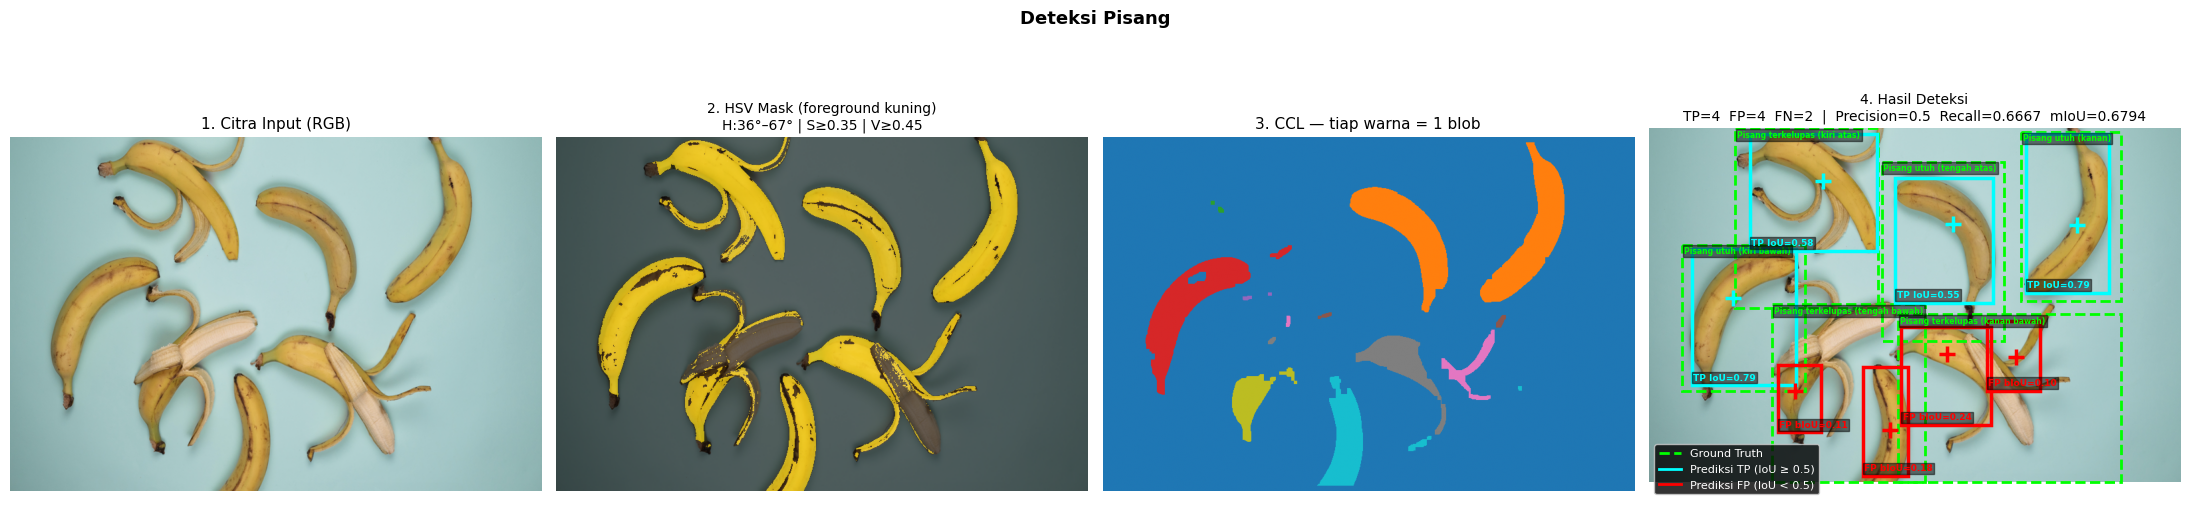

Visualisasi disimpan: hasil_deteksi_pisang.png


In [43]:
URL        = "https://drive.google.com/uc?export=download&id=1Ov7KU5TR3HCAfDAqamwZDnF6lH0sUbay"
IMAGE_PATH = "pisang.jpg"
urllib.request.urlretrieve(URL, IMAGE_PATH)
print("File tersimpan sebagai:", IMAGE_PATH)

# Bounding box [x1, y1, x2, y2]
GT_BOXES = [
    [130, 0,   345, 270],   # GT1
    [350, 50,  535, 320],   # GT2
    [560, 5,   710, 260],   # GT3
    [50,  175, 235, 395],   # GT4
    [185, 265, 415, 533],   # GT5
    [375, 280, 710, 533],   # GT6
]
GT_LABELS = [
    "Pisang terkelupas (kiri atas)",
    "Pisang utuh (tengah atas)",
    "Pisang utuh (kanan)",
    "Pisang utuh (kiri bawah)",
    "Pisang terkelupas (tengah bawah)",
    "Pisang terkelupas (kanan bawah)",
]

# (1) RGB → HSV
def rgb_to_hsv(img_rgb):
    r = img_rgb[:,:,0] / 255.0
    g = img_rgb[:,:,1] / 255.0
    b = img_rgb[:,:,2] / 255.0

    Cmax  = np.maximum(np.maximum(r, g), b)
    Cmin  = np.minimum(np.minimum(r, g), b)
    delta = Cmax - Cmin

    V = Cmax
    S = np.where(Cmax > 0, delta / Cmax, 0.0)

    H   = np.zeros_like(V)
    m_r = (Cmax == r) & (delta > 0)
    m_g = (Cmax == g) & (delta > 0)
    m_b = (Cmax == b) & (delta > 0)
    H[m_r] = (60 * ((g[m_r] - b[m_r]) / delta[m_r]) % 360) / 360
    H[m_g] = (60 * ((b[m_g] - r[m_g]) / delta[m_g] + 2) % 360) / 360
    H[m_b] = (60 * ((r[m_b] - g[m_b]) / delta[m_b] + 4) % 360) / 360
    return H, S, V


# (2) HSV Color Thresholding
def color_threshold(H, S, V, h_min=0.100, h_max=0.185, s_min=0.35, v_min=0.45):
    return ((H >= h_min) & (H <= h_max) &
            (S >= s_min) & (V >= v_min)).astype(np.uint8)


# (3) Morphological Operations
def erode(binary, k=3):
    H, W = binary.shape; p = k // 2
    out  = np.zeros_like(binary)
    for y in range(p, H - p):
        for x in range(p, W - p):
            if binary[y-p:y+p+1, x-p:x+p+1].sum() == k * k:
                out[y, x] = 1
    return out

def dilate(binary, k=3):
    H, W = binary.shape; p = k // 2
    out  = np.zeros_like(binary)
    for y in range(p, H - p):
        for x in range(p, W - p):
            if binary[y-p:y+p+1, x-p:x+p+1].sum() > 0:
                out[y, x] = 1
    return out

def opening(binary, k=5):
    return dilate(erode(binary, k), k)

def closing(binary, k=9):
    return erode(dilate(binary, k), k)


# (4) CCL
def ccl_4connectivity(binary):
    H, W      = binary.shape
    label_map = np.zeros((H, W), dtype=np.int32)
    parent    = [0]; next_lbl = 1

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    for y in range(H):
        for x in range(W):
            if binary[y, x] == 0: continue
            nb = []
            if y > 0 and label_map[y-1, x] > 0: nb.append(label_map[y-1, x])
            if x > 0 and label_map[y, x-1] > 0: nb.append(label_map[y, x-1])
            if not nb:
                parent.append(next_lbl); label_map[y, x] = next_lbl; next_lbl += 1
            else:
                label_map[y, x] = nb[0]
                for n in nb[1:]: union(nb[0], n)

    resolved = {}; n_labels = 0
    for y in range(H):
        for x in range(W):
            lbl = label_map[y, x]
            if lbl == 0: continue
            root = find(lbl)
            if root not in resolved: n_labels += 1; resolved[root] = n_labels
            label_map[y, x] = resolved[root]
    return label_map, n_labels


# (5) Bounding Box
def extract_boxes(label_map, n_labels, min_area=800):
    boxes = []
    for lbl in range(1, n_labels + 1):
        ys, xs = np.where(label_map == lbl)
        if len(ys) < min_area: continue
        boxes.append({
            "label": lbl,
            "x1": int(xs.min()), "y1": int(ys.min()),
            "x2": int(xs.max()), "y2": int(ys.max()),
            "area": int(len(ys)),
            "centroid": (int(xs.mean()), int(ys.mean())),
        })
    boxes.sort(key=lambda b: (b["y1"] + b["y2"]) / 2)
    return boxes


# (6) Evaluasi: IoU, Precision, Recall
def compute_iou(a, b, verbose=False):
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])

    inter  = (ix2 - ix1) * (iy2 - iy1) if ix2 > ix1 and iy2 > iy1 else 0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union  = area_a + area_b - inter
    iou_val = inter / union if union > 0 else 0.0

    if verbose:
        print(f"    Intersection : ({ix2}-{ix1}) × ({iy2}-{iy1}) = {inter} px²")
        print(f"    Area Pred    : ({a[2]}-{a[0]}) × ({a[3]}-{a[1]}) = {area_a} px²")
        print(f"    Area GT      : ({b[2]}-{b[0]}) × ({b[3]}-{b[1]}) = {area_b} px²")
        print(f"    Union        : {area_a} + {area_b} - {inter} = {union} px²")
        print(f"    IoU          : {inter} / {union} = {iou_val:.4f}")
    return iou_val


def evaluate(pred_boxes, gt_boxes, iou_threshold=0.5):
    pairs = []
    for pi, pb in enumerate(pred_boxes):
        pbl = [pb["x1"], pb["y1"], pb["x2"], pb["y2"]]
        for gi, gb in enumerate(gt_boxes):
            pairs.append((compute_iou(pbl, gb), pi, gi))
    pairs.sort(key=lambda t: -t[0])

    matched_p, matched_g = set(), set()
    iou_vals = {}
    for v, pi, gi in pairs:
        if pi in matched_p or gi in matched_g: continue
        if v >= iou_threshold:
            matched_p.add(pi); matched_g.add(gi); iou_vals[pi] = v

    best_iou = {}
    for v, pi, _ in sorted(pairs, key=lambda t: -t[0]):
        if pi not in best_iou: best_iou[pi] = v

    TP = len(matched_p); FP = len(pred_boxes) - TP; FN = len(gt_boxes) - TP
    P  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    R  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    F1 = 2*P*R / (P + R) if (P + R) > 0 else 0.0
    mIoU = float(np.mean(list(iou_vals.values()))) if iou_vals else 0.0

    return {"TP": TP, "FP": FP, "FN": FN,
            "Precision": round(P, 4), "Recall": round(R, 4),
            "F1-Score": round(F1, 4), "mIoU": round(mIoU, 4)
            }, best_iou, matched_p


# (7) Visualisasi
def visualize(img_rgb, mask_raw, label_map, pred_boxes,
              gt_boxes, gt_labels, metrics, best_iou, matched_p):
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle("Deteksi Pisang", fontsize=13, fontweight='bold')

    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Citra Input (RGB)", fontsize=11); axes[0].axis('off')

    overlay = np.zeros((*img_rgb.shape[:2], 3), dtype=np.uint8)
    overlay[mask_raw == 1] = [255, 220, 0]
    blended = (img_rgb.astype(np.float32)*0.45 +
               overlay.astype(np.float32)*0.55).clip(0,255).astype(np.uint8)
    axes[1].imshow(blended)
    axes[1].set_title("2. HSV Mask (foreground kuning)\nH:36°–67° | S≥0.35 | V≥0.45",
                      fontsize=10); axes[1].axis('off')

    axes[2].imshow(label_map, cmap='tab10')
    axes[2].set_title("3. CCL — tiap warna = 1 blob", fontsize=11); axes[2].axis('off')

    axes[3].imshow(img_rgb)
    for i, gt in enumerate(gt_boxes):
        axes[3].add_patch(patches.Rectangle(
            (gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
            lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
        axes[3].text(gt[0]+3, gt[1]+14, gt_labels[i], color='lime',
                     fontsize=5.5, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))

    for i, b in enumerate(pred_boxes):
        iou_v = best_iou.get(i, 0.0); is_tp = i in matched_p
        color = 'cyan' if is_tp else 'red'
        tag   = f"TP IoU={iou_v:.2f}" if is_tp else \
                (f"FP bIoU={iou_v:.2f}" if iou_v > 0 else "FP")
        axes[3].add_patch(patches.Rectangle(
            (b["x1"], b["y1"]), b["x2"]-b["x1"], b["y2"]-b["y1"],
            lw=2.5, edgecolor=color, facecolor='none'))
        axes[3].text(b["x1"]+2, b["y2"]-8, tag, color=color, fontsize=6.5,
                     fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=1))
        cx, cy = b["centroid"]; axes[3].plot(cx, cy, '+', color=color, markersize=11, mew=2.5)

    legend = [Line2D([0],[0], color='lime', ls='--', lw=2, label='Ground Truth'),
              Line2D([0],[0], color='cyan', ls='-',  lw=2, label='Prediksi TP (IoU ≥ 0.5)'),
              Line2D([0],[0], color='red',  ls='-',  lw=2, label='Prediksi FP (IoU < 0.5)')]
    axes[3].legend(handles=legend, fontsize=8, loc='lower left',
                   facecolor='black', labelcolor='white')
    axes[3].set_title(
        f"4. Hasil Deteksi\n"
        f"TP={metrics['TP']}  FP={metrics['FP']}  FN={metrics['FN']}  |  "
        f"Precision={metrics['Precision']}  Recall={metrics['Recall']}  mIoU={metrics['mIoU']}",
        fontsize=10); axes[3].axis('off')

    plt.tight_layout()
    plt.savefig("hasil_deteksi_pisang.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Visualisasi disimpan: hasil_deteksi_pisang.png")


def main():
    print("[1] Load citra")
    pil     = Image.open(IMAGE_PATH).convert("RGB")
    pil     = pil.resize((800, 533))
    img_rgb = np.array(pil)
    print(f"    Ukuran: {img_rgb.shape[1]} × {img_rgb.shape[0]} piksel")

    print("[2] Konversi RGB → HSV")
    H, S, V = rgb_to_hsv(img_rgb)

    print("[3] HSV Color Thresholding (background teal)")
    mask_raw = color_threshold(H, S, V, h_min=0.100, h_max=0.185, s_min=0.35, v_min=0.45)
    print(f"    Piksel foreground: {mask_raw.sum():,} / {mask_raw.size:,}")

    print("[4] Morphological Opening (k=5) → Closing (k=9)")
    binary = closing(opening(mask_raw, k=5), k=9)

    print("[5] Connected Component Labeling (CCL 4-connectivity)")
    label_map, n_raw = ccl_4connectivity(binary)
    print(f"    Blob ditemukan: {n_raw}")

    MIN_AREA = 800
    print(f"[6] Ekstrak Bounding Box (min_area={MIN_AREA}px)")
    pred_boxes = extract_boxes(label_map, n_raw, min_area=MIN_AREA)
    print(f"    Objek lolos filter: {len(pred_boxes)}")
    for i, b in enumerate(pred_boxes):
        print(f"      Pred{i+1}: [{b['x1']},{b['y1']},{b['x2']},{b['y2']}]  "
              f"area={b['area']}px  centroid={b['centroid']}")

    print("\n[7] Perhitungan IoU per prediksi:")
    for pi, pb in enumerate(pred_boxes):
        pbl = [pb["x1"], pb["y1"], pb["x2"], pb["y2"]]
        best_v = 0; best_gi = -1
        for gi, gb in enumerate(GT_BOXES):
            v = compute_iou(pbl, gb)
            if v > best_v: best_v = v; best_gi = gi
        if best_gi >= 0:
            print(f"Pred{pi+1} {pbl}  ↔  GT{best_gi+1} {GT_BOXES[best_gi]}")
            compute_iou(pbl, GT_BOXES[best_gi], verbose=True)

    print(f"\n[8] Evaluasi (threshold IoU = 0.5)")
    metrics, best_iou, matched_p = evaluate(pred_boxes, GT_BOXES, iou_threshold=0.5)
    print(f"    TP = {metrics['TP']}  |  FP = {metrics['FP']}  |  FN = {metrics['FN']}")
    print(f"    Precision  = TP/(TP+FP) = {metrics['TP']}/({metrics['TP']}+{metrics['FP']}) = {metrics['Precision']}")
    print(f"    Recall     = TP/(TP+FN) = {metrics['TP']}/({metrics['TP']}+{metrics['FN']}) = {metrics['Recall']}")
    print(f"    F1-Score   = 2×P×R/(P+R) = {metrics['F1-Score']}")
    print(f"    Mean IoU   = {metrics['mIoU']}")

    print("\n[9] Visualisasi")
    visualize(img_rgb, mask_raw, label_map, pred_boxes,
              GT_BOXES, GT_LABELS, metrics, best_iou, matched_p)


if __name__ == "__main__":
    main()

**Analisis Hasil Segmentasi** <br>
Dari enam objek GT, pipeline menghasilkan delapan prediksi dengan 4 deteksi TP. Empat prediksi lainnya sebagai FP karena IoU di bawah threshold dan dua objek lainnya (GT5, GT6) sebagai FN. <br>

Dari ketiga kasus (jeruk1, jeruk2, dan pisang), Recall = 0.6667 adalah yang tertinggi. Namun, Precision = 0.5 menunjukkan bahwa separuh prediksi tidak valid sehingga F1-Score = 0.5714 tercermin lebih seimbang. <br>

Pred2 dan Pred4 (pisang utuh) ini adalah dua prediksi terbaik karena area prediksinya tidak menyebar berlebihkan keluar objel. Berbeda dengan pisang yang terkelupas, blob yang terbentuk bukan satu region utuh sehingga muncul sebagai prediksi tersendiri dan IoU-nya tidak cukup besar.

####**Kesimpulan**
*   Jeruk yang karakteristiknya homogen ini cocok dilakukan metode segmentasi. Namun, rendahnya akurasi deteksi pada gambar jeruk1 disebabkan oleh adanya ambiguitas kromatik antara kulit jeruk dan talenan di latar. Kondisi ini merupakan limitasi dari segmentasi berbasis thresholding HSV karena ketidakmampuannya melokalisasi dengan presisi yang cukup untuk memenuhi threshold IoU. Berbeda dengan latar putih yang memberikan kondisi yang lebih kondusif bagi segmentasi berbasis warna.
*   Kedekatan spasial antarobjek ternyata juga memengaruhi hasil deteksi, yakni nilai kernel yang cukup besar untuk menutup lubang akan berisiko menyambungkan objek yang berdekatan. Pendekatan yang lebih adaptif diperlukan untuk memisahkan blob yang berdekatan seperti pada gambar jeruk2.
*   Pisang memiliki karakter intrinsik yang unik dibanding jeruk. Pada pisang terkelupas, saturasi dagingnya mendekati nol sehingga di luar rentang filter HSV untuk warna kuning. Selain itu, bentuknya melengkung dan memanjang sehingga cenderung membuat bounding box tidak menutup seluruh objek secara presisi.





####**Referensi** <br>
*   Everingham, M., Van Gool, L., Williams, C.K.I. et al. The Pascal Visual Object Classes (VOC) Challenge. Int J Comput Vis 88, 303–338 (2010). https://doi.org/10.1007/s11263-009-0275-4
*   Wahyono. (n.d.). Background modeling [Slide kuliah]. Departemen Ilmu Komputer dan Elektronika, FMIPA, Universitas Gadjah Mada.
*   Wahyono. (n.d.). Segmentation: Thresholding [Slide kuliah]. Departemen Ilmu Komputer dan Elektronika, FMIPA, Universitas Gadjah Mada.
*  Wahyono. (n.d.). Object detection using sliding window [Slide kuliah]. Departemen Ilmu Komputer dan Elektronika, FMIPA, Universitas Gadjah Mada.





